# imports

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dowhy import CausalModel
import dowhy.datasets
# set the style of the plots

# tutorial 1

https://www.pywhy.org/dowhy/v0.9.1/user_guide/intro.html

In [32]:
data = dowhy.datasets.linear_dataset(
    beta=10,
    num_common_causes=5,
    num_instruments=2,
    num_samples=10000,
    treatment_is_binary=True)

In [36]:
data.keys()

dict_keys(['df', 'treatment_name', 'outcome_name', 'common_causes_names', 'instrument_names', 'effect_modifier_names', 'frontdoor_variables_names', 'dot_graph', 'gml_graph', 'ate'])

In [38]:
data['df'].head()

,Z0,Z1,W0,W1,W2,W3,W4,v0,y
0,0.0,0.824389,0.285646,0.205217,-1.791485,-0.263214,1.160213,True,10.144604
1,0.0,0.721512,-0.477527,-0.321246,-1.566207,-0.166420,1.082951,False,-3.473760
2,0.0,0.593529,0.948141,2.427603,-0.750597,-0.561053,0.678461,True,22.518965
3,1.0,0.011091,0.463142,1.323692,-1.281564,-1.362284,-0.175581,True,8.462496
4,0.0,0.076699,0.454015,1.510073,-3.408520,-1.326111,2.510524,False,4.443473


In [40]:
data['gml_graph']

'graph[directed 1node[ id "y" label "y"]node[ id "W0" label "W0"] node[ id "W1" label "W1"] node[ id "W2" label "W2"] node[ id "W3" label "W3"] node[ id "W4" label "W4"]node[ id "Z0" label "Z0"] node[ id "Z1" label "Z1"]node[ id "v0" label "v0"]edge[source "v0" target "y"]edge[ source "W0" target "v0"] edge[ source "W1" target "v0"] edge[ source "W2" target "v0"] edge[ source "W3" target "v0"] edge[ source "W4" target "v0"]edge[ source "Z0" target "v0"] edge[ source "Z1" target "v0"]edge[ source "W0" target "y"] edge[ source "W1" target "y"] edge[ source "W2" target "y"] edge[ source "W3" target "y"] edge[ source "W4" target "y"]]'

In [74]:
# I. Create a causal model from the data and given graph.
model = CausalModel(
    data=data["df"],
    treatment=data["treatment_name"],
    outcome=data["outcome_name"],
    graph=data["gml_graph"])

# II. Identify causal effect and return target estimands
identified_estimand = model.identify_effect()

# III. Estimate the target estimand using a statistical method.
estimate = model.estimate_effect(identified_estimand,
                                 method_name="backdoor.propensity_score_matching")

# IV. Refute the obtained estimate using multiple robustness checks.
refute_results = model.refute_estimate(identified_estimand, estimate,
                                       method_name="random_common_cause")

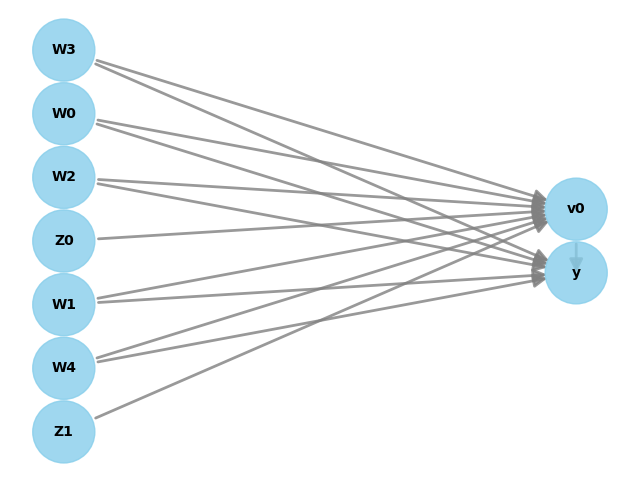

In [70]:
model.view_model()

In [75]:
print(estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d                       
─────(E[y|W4,W1,W3,W2,W0])
d[v₀]                     
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W4,W1,W3,W2,W0,U) = P(y|v0,W4,W1,W3,W2,W0)

## Realized estimand
b: y~v0+W4+W1+W3+W2+W0
Target units: ate

## Estimate
Mean value: 10.10207106530075



In [76]:
res_random=model.refute_estimate(identified_estimand, estimate, method_name="random_common_cause", show_progress_bar=True)
print(res_random)

Refuting Estimates: 100%|██████████| 100/100 [00:00<00:00, 135.64it/s]

Refute: Add a random common cause
Estimated effect:10.10207106530075
New effect:10.102071065300748
p value:1.0



In [77]:
estimate_new = model.estimate_effect(identified_estimand,
    method_name="backdoor.propensity_score_matching")
res_placebo = model.refute_estimate(identified_estimand, estimate_new,
    method_name="placebo_treatment_refuter", show_progress_bar=True)
print(res_placebo)

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refuting Estimates: 100%|██████████| 100/100 [00:00<00:00, 100.10it/s]

Refute: Use a Placebo Treatment
Estimated effect:10.10207106530075
New effect:0.004471797603646376
p value:0.9199999999999999



In [78]:
res_subset=model.refute_estimate(identified_estimand, estimate,
        method_name="data_subset_refuter", show_progress_bar=True, subset_fraction=0.9)
print(res_subset)

Refuting Estimates: 100%|██████████| 100/100 [00:00<00:00, 131.05it/s]

Refute: Use a subset of data
Estimated effect:10.10207106530075
New effect:10.124126435516605
p value:0.96



# lalonde dataset

In [11]:
data = dowhy.datasets.lalonde_dataset()

In [18]:
data.head()

,treat,age,educ,black,hisp,married,nodegr,re74,re75,re78,u74,u75
0,False,23.0,10.0,1.0,0.0,0.0,1.0,0.0,0.0,0.00,1.0,1.0
1,False,26.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,12383.68,1.0,1.0
2,False,22.0,9.0,1.0,0.0,0.0,1.0,0.0,0.0,0.00,1.0,1.0
3,False,18.0,9.0,1.0,0.0,0.0,1.0,0.0,0.0,10740.08,1.0,1.0
4,False,45.0,11.0,1.0,0.0,0.0,1.0,0.0,0.0,11796.47,1.0,1.0


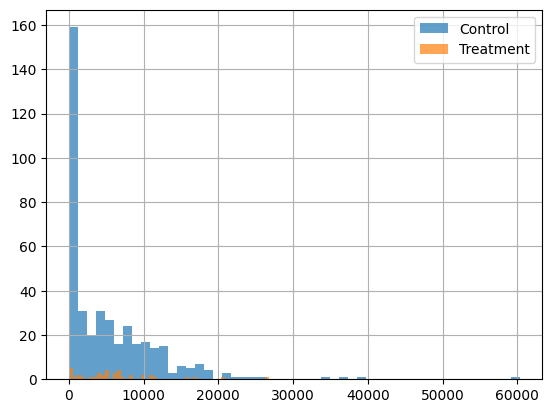

In [30]:
data.groupby('hisp')['re78'].hist(bins=50, alpha=0.7)
plt.legend(['Control', 'Treatment'])
plt.show()